Initial loss = 10.647098786907069
differential_evolution step 1: f(x)= 0.40506131040351956
differential_evolution step 2: f(x)= 0.40506131040351956
differential_evolution step 3: f(x)= 0.40506131040351956
differential_evolution step 4: f(x)= 0.40506131040351956
differential_evolution step 5: f(x)= 0.40506131040351956
differential_evolution step 6: f(x)= 0.40506131040351956
differential_evolution step 7: f(x)= 0.40506131040351956
differential_evolution step 8: f(x)= 0.40506131040351956
differential_evolution step 9: f(x)= 0.3224002695383376
differential_evolution step 10: f(x)= 0.314071710333538
differential_evolution step 11: f(x)= 0.314071710333538
differential_evolution step 12: f(x)= 0.314071710333538
differential_evolution step 13: f(x)= 0.314071710333538
differential_evolution step 14: f(x)= 0.314071710333538
differential_evolution step 15: f(x)= 0.314071710333538
differential_evolution step 16: f(x)= 0.314071710333538
differential_evolution step 17: f(x)= 0.314071710333538
differ

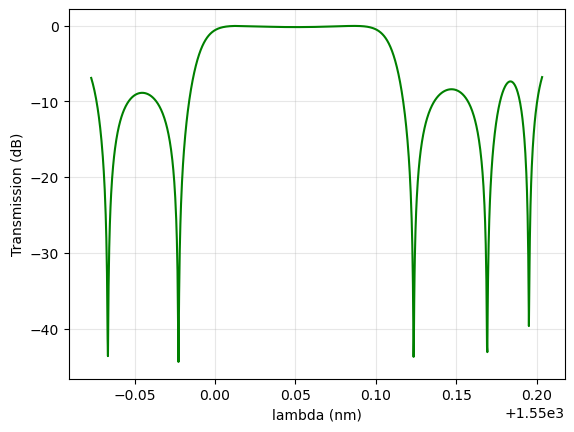

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution

# ============================================================
# 1. 参数定义
# ============================================================
# 物理常数
c = 3e8                              # 光速 (m/s)

# 频率扫描（对应 Matlab 中的 f）
f = np.arange(
    1.93523e14,                      # 扫描起始频率 (Hz)
    1.93558e14 + 0.00000025e14,      # 扫描终止频率 (Hz)
    0.00000025e14                    # 频率步进 (Hz)
)

# 输入光场
E1 = 0.0 + 0.0j                     # 输入端口 1（未激励）
E2 = 1.0 + 0.0j                     # 输入端口 2（激励）

# 输入 / 输出 MZI 的 50:50 耦合器
Ki = 0.5                             # 输入 MZI 耦合器功率耦合系数
Ko = 0.5                             # 输出 MZI 耦合器功率耦合系数

# 输入 / 输出 MZI 的单臂相移
thetai = 0.5 * np.pi                # 输入 MZI 下臂相移
thetao = 0.5 * np.pi                # 输出 MZI 下臂相移

# 可优化参数：微环静态相位偏置（阶段 1 优化）
fai1 = -0.0468 * np.pi              # Ring 1 相位偏置
fai2 = -0.6842 * np.pi              # Ring 2 相位偏置
fai3 = -0.0518 * np.pi              # Ring 3 相位偏置
fai4 = -0.6198 * np.pi              # Ring 4 相位偏置

# 可优化参数：微环等效耦合相位（对称约束）
theta_r1 = -0.622 * np.pi           # Ring 1 与 Ring 3 的等效耦合相位
theta_r2 = -0.73  * np.pi           # Ring 2 与 Ring 4 的等效耦合相位

# 可优化参数：MZI 两臂相位（满足 fait = -faib，阶段 2 优化）
phi_mzi = 0.495 * np.pi             # MZI 臂相位幅值

# 波导与损耗参数
Alfadb = 15                         # 功率损耗 (dB/cm)
alfadb = Alfadb / 2                 # 场强损耗 (dB/cm)
alfa = alfadb * np.log(10) / 10     # 场强损耗系数 (1/m)
ng = 4.3                            # 群折射率

# 微环等效光程长度
L1 = 350e-6                         # Ring 1 长度 (m)
L2 = 3000e-6                        # Ring 2 长度 (m)
L3 = 350e-6                         # Ring 3 长度 (m)
L4 = 3000e-6                        # Ring 4 长度 (m)

# 场强损耗
tao1 = np.exp(-alfa * L1)
tao2 = np.exp(-alfa * L2)
tao3 = np.exp(-alfa * L3)
tao4 = np.exp(-alfa * L4)

# 单圈传播相位
phi1 = 2 * np.pi * f * L1 * ng / c
phi2 = 2 * np.pi * f * L2 * ng / c
phi3 = 2 * np.pi * f * L3 * ng / c
phi4 = 2 * np.pi * f * L4 * ng / c

# ============================================================
# 2. 基础模块
# ============================================================

# 耦合器模型
def coupler(Ea, Eb, K):
    t = np.sqrt(1 - K)
    return (
        t * Ea - 1j * np.sqrt(K) * Eb,
        -1j * np.sqrt(K) * Ea + t * Eb
    )

# all-pass 微环传输函数
def all_pass_ring(theta, fai0, phi, tao):
    num = (np.exp(1j*theta) - 1)/2 - tao * np.exp(1j*(fai0 + theta + phi))
    den = 1 - tao * (1 - np.exp(1j*theta)) * np.exp(1j*(phi + fai0)) / 2
    return num / den


# ============================================================
# 3. 仿真与损失函数
# ============================================================

def simulate(params):

    # -------- 解包待优化参数 --------
    fai1, fai2, fai3, fai4, theta_r1, theta_r2, phi_mzi = params

    # -------- 派生参数（约束关系）--------
    theta1 = theta3 = theta_r1
    theta2 = theta4 = theta_r2

    fait = +phi_mzi      # MZI 上臂相位
    faib = -phi_mzi      # MZI 下臂相位

    # -------- 输入 MZI --------
    E_up, E_dn = coupler(E1, E2, Ki)
    E_up, E_dn = coupler(E_up, np.exp(1j * thetai) * E_dn, Ki)

    # -------- 四个微环 --------
    H1 = all_pass_ring(theta1, fai1, phi1, tao1)
    H2 = all_pass_ring(theta2, fai2, phi2, tao2)
    H3 = all_pass_ring(theta3, fai3, phi3, tao3)
    H4 = all_pass_ring(theta4, fai4, phi4, tao4)

    E_up = np.exp(1j * fait) * H1 * H2 * E_up
    E_dn = np.exp(1j * faib) * H3 * H4 * E_dn

    # -------- 输出 MZI（Cross 端口）--------
    E_up, E_dn = coupler(E_up, E_dn, Ko)
    _, E_cross = coupler(E_up, np.exp(1j * thetao) * E_dn, Ko)

    # -------- 功率谱 --------
    C2 = np.abs(E_cross)**2
    CdB2 = 10 * np.log10(C2)
    lambda_nm = (c / f) * 1e9

    return lambda_nm, CdB2

def loss(params, lambda_c=1550.05, BW=0.1, stop_db=-60,
         w_pass=5.0, w_stop=1.0, w_ripple=0.5):

    lambda_nm, CdB2 = simulate(params)

    passband = np.abs(lambda_nm - lambda_c) <= BW/2
    stopband = ~passband

    # 理想方波（dB）
    ideal_dB = np.where(passband, 0.0, stop_db)

    # 转线性功率做 MSE（更平滑）
    P_real  = 10**(CdB2 / 10)
    P_ideal = 10**(ideal_dB / 10)

    mse_pass = np.mean((P_real[passband] - P_ideal[passband])**2)
    mse_stop = np.mean((P_real[stopband] - P_ideal[stopband])**2)

    # 额外加一个通带“平坦度”项（防止通带内出现凹陷/波纹）
    ripple = np.std(CdB2[passband])   # 或 max-min 也行

    return w_pass*mse_pass + w_stop*mse_stop + w_ripple*ripple

# ============================================================
# 4. 主计算流程
# ============================================================

# 初始参数（用你在参数区写的默认值）
params0 = [
    fai1, fai2, fai3, fai4,
    theta_r1, theta_r2,
    phi_mzi
]

# （可选）先跑一次看看初始谱线和 loss
lambda_nm, CdB2 = simulate(params0)
print("Initial loss =", loss(params0))

# （可选）跑 DE 优化：想跑就取消下面这段注释
bounds = [(-np.pi, np.pi)] * 7
result = differential_evolution(
    loss,
    bounds=bounds,
    maxiter=200,
    popsize=20,
    polish=False,
    disp=True
)
print("Best loss =", result.fun)
print("Best params =", result.x)
lambda_nm, CdB2 = simulate(result.x)   # 用最优参数重新仿真


# ============================================================
# 5. 绘图
# ============================================================

plt.plot(lambda_nm, CdB2, 'g')
#plt.xlim(1549.9, 1550.2)
#plt.ylim(-60, 1)
plt.xlabel("lambda (nm)")
plt.ylabel("Transmission (dB)")
plt.grid(True, alpha=0.3)
plt.show()